# Assignment 4 - Part 2: Handling Imbalanced Data

This notebook solves Part 2 only. The goal is to study imbalanced binary classification on the Tehran apartment/rental-style dataset in `Data.csv`.

The original dataset has a `parking` column. We convert it into a clearer minority-positive target:

- `no_parking = 0`: the apartment has parking.
- `no_parking = 1`: the apartment does not have parking.

The positive class is the minority class, so precision, recall, F1, PR-AUC, and confusion matrices are easier to interpret.


## Imports and Configuration

We import the standard data-science libraries, scikit-learn tools, and imbalanced-learn samplers. 


In [1]:
from pathlib import Path
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.over_sampling import RandomOverSampler, SMOTE
except ImportError as exc:
    raise ImportError(
        "imbalanced-learn is required for this notebook. Install it with: pip install imbalanced-learn"
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TARGET_COL = "no_parking"

DATA_PATH_CANDIDATES = [Path("Data.csv"), Path("data") / "Data.csv"]
OUTPUT_DIR = Path("outputs")
REPORTS_DIR = Path("reports")
OUTPUT_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## Helper Functions

These helper functions keep the notebook reproducible and avoid repeated code. They also make validation explicit: we check required columns, binary columns, duplicates, numeric ranges, and class distributions before modeling.


In [2]:
def load_dataset(path_candidates):
    """Load the first existing CSV from a list of relative path candidates."""
    for path in path_candidates:
        if path.exists():
            return pd.read_csv(path), path
    candidates = ", ".join(str(path) for path in path_candidates)
    raise FileNotFoundError(f"Data.csv was not found. Checked: {candidates}")


def standardize_column_names(df):
    """Make a safe copy with stripped lowercase column names."""
    result = df.copy()
    result.columns = [str(col).strip().lower() for col in result.columns]
    return result


def rename_known_typos(df):
    """Rename known typos in the cleaned dataframe only."""
    return df.rename(columns={"elavator": "elevator"})


def validate_required_columns(df, required_columns):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    return True


def validate_binary_column(df, col):
    values = sorted(pd.Series(df[col].dropna().unique()).tolist())
    if values != [0, 1]:
        raise ValueError(f"Column {col!r} must be binary with values [0, 1]. Found: {values}")
    return True


def create_target_no_parking(df):
    """Create the minority-positive target no_parking = 1 - parking."""
    validate_binary_column(df, "parking")
    result = df.copy()
    result[TARGET_COL] = 1 - result["parking"]
    return result


def report_basic_quality(df):
    return pd.DataFrame(
        {
            "metric": ["rows", "columns", "missing_values", "duplicated_rows"],
            "value": [df.shape[0], df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum())],
        }
    )


def remove_duplicate_rows(df):
    """Remove duplicates if they exist; for this dataset it should keep all rows."""
    duplicate_count = int(df.duplicated().sum())
    if duplicate_count == 0:
        return df.copy()
    return df.drop_duplicates().reset_index(drop=True)


def validate_numeric_ranges(df):
    """Summarize numeric ranges and flag values worth reviewing without dropping them."""
    numeric_cols = ["total_value", "area", "year", "deposit", "rent"]
    rows = []
    for col in numeric_cols:
        series = pd.to_numeric(df[col], errors="coerce")
        q99 = series.quantile(0.99)
        notes = []
        if col == "area" and series.max() > 1000:
            notes.append("area max is extremely large for a normal apartment")
        if col in ["deposit", "rent"] and (series == 0).sum() > 0:
            notes.append("contains zero values")
        if q99 > 0 and series.max() > 5 * q99:
            notes.append("max is far above the 99th percentile")
        rows.append(
            {
                "column": col,
                "min": series.min(),
                "median": series.median(),
                "q99": q99,
                "max": series.max(),
                "zero_count": int((series == 0).sum()),
                "note": "; ".join(notes) if notes else "ok / review with domain knowledge",
            }
        )
    return pd.DataFrame(rows)


def summarize_class_distribution(y):
    counts = pd.Series(y).value_counts().sort_index()
    return pd.DataFrame(
        {
            "class": counts.index,
            "count": counts.values,
            "percent": (counts.values / counts.sum() * 100).round(2),
        }
    )


def capture_info(df):
    buffer = io.StringIO()
    df.info(buf=buffer)
    return buffer.getvalue()


## Data Loading and Quick Inspection

We first load the raw CSV exactly as it is. This step checks the basic facts of the dataset before any cleaning or target engineering.


In [3]:
df, DATA_PATH = load_dataset(DATA_PATH_CANDIDATES)
print(f"Loaded dataset from: {DATA_PATH}")

display(df.head())
print(f"Shape: {df.shape}")
print(capture_info(df))


Loaded dataset from: Data.csv


,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse
0,"2,000,900,000.0000",ولنجک,270,1399,"2,000,000,000.0000","30,000,000.0000",1,1,1
1,"200,120,000.0000",کوی فردوس,70,1387,"200,000,000.0000","4,000,000.0000",0,1,1
2,"350,255,000.0000",پونک,120,1395,"350,000,000.0000","8,500,000.0000",1,1,1
3,"200,300,000.0000",هروی,110,1395,"200,000,000.0000","10,000,000.0000",1,1,1
4,"200,180,000.0000",پونک,80,1387,"200,000,000.0000","6,000,000.0000",1,1,1


Shape: (12383, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12383 entries, 0 to 12382
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   total_value   12383 non-null  float64
 1   neighborhood  12383 non-null  object 
 2   area          12383 non-null  int64  
 3   year          12383 non-null  int64  
 4   deposit       12383 non-null  float64
 5   rent          12383 non-null  float64
 6   elavator      12383 non-null  int64  
 7   parking       12383 non-null  int64  
 8   warehouse     12383 non-null  int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 870.8+ KB



The next tables check missing values, duplicated rows, data types, binary columns, neighborhood cardinality, and numeric summaries. These are the basic EDA checks used before building a model.


In [4]:
missing_table = df.isna().sum().rename("missing_count").to_frame()
missing_table["missing_percent"] = (missing_table["missing_count"] / len(df) * 100).round(2)
dtype_table = df.dtypes.astype(str).rename("dtype").to_frame()

display(report_basic_quality(df))
display(missing_table)
display(dtype_table)
print(f"Duplicated rows: {int(df.duplicated().sum())}")

for col in ["parking", "elavator", "warehouse"]:
    display(df[col].value_counts(dropna=False).sort_index().rename_axis(col).reset_index(name="count"))

print(f"Unique neighborhoods: {df['neighborhood'].nunique()}")
display(df["neighborhood"].value_counts().head(10).rename_axis("neighborhood").reset_index(name="count"))
display(df.describe(include="all"))


,metric,value
0,rows,12383
1,columns,9
2,missing_values,0
3,duplicated_rows,0


,missing_count,missing_percent
total_value,0,0.0000
neighborhood,0,0.0000
area,0,0.0000
year,0,0.0000
deposit,0,0.0000
rent,0,0.0000
elavator,0,0.0000
parking,0,0.0000
warehouse,0,0.0000


,dtype
total_value,float64
neighborhood,object
area,int64
year,int64
deposit,float64
rent,float64
elavator,int64
parking,int64
warehouse,int64


Duplicated rows: 0


,parking,count
0,0,1425
1,1,10958


,elavator,count
0,0,2398
1,1,9985


,warehouse,count
0,0,2
1,1,12381


Unique neighborhoods: 314


,neighborhood,count
0,سعادت‌آباد,976
1,نیاوران,562
2,پونک,515
3,فرمانیه,442
4,الهیه,416
5,زعفرانیه,396
6,کوی فردوس,358
7,پاسداران,332
8,قیطریه,328
9,ولنجک,315


,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse
count,"12,383.0000",12383,"12,383.0000","12,383.0000","12,383.0000","12,383.0000","12,383.0000","12,383.0000","12,383.0000"
unique,NaN,314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,سعادت‌آباد,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,"495,842,144.7780",NaN,171.5212,"1,391.6825","495,288,202.5737","18,464,740.1446",0.8063,0.8849,0.9998
std,"885,827,628.0406",NaN,"2,979.6459",6.6864,"885,692,488.6119","477,377,367.2907",0.3952,0.3191,0.0127
min,0.0000,NaN,5.0000,"1,363.0000",0.0000,0.0000,0.0000,0.0000,0.0000
25%,"100,180,000.0000",NaN,80.0000,"1,387.0000","100,000,000.0000",0.0000,1.0000,1.0000,1.0000
50%,"300,000,000.0000",NaN,115.0000,"1,393.0000","300,000,000.0000","1,500,000.0000",1.0000,1.0000,1.0000
75%,"550,900,000.0000",NaN,155.0000,"1,397.0000","550,000,000.0000","8,000,000.0000",1.0000,1.0000,1.0000


## Target Selection and Imbalance Explanation

The assignment is about imbalanced data. `parking` is a good source for an imbalanced target because it has a clear minority class but still enough samples for stratified splitting and SMOTE.

We do not use `warehouse` as the target because it has only 2 samples in the minority class. That is too extreme for reliable evaluation and unsafe for SMOTE.


,class,count,percent,meaning
0,0,1425,11.5100,does not have parking
1,1,10958,88.4900,has parking


,class,count,percent,meaning
0,0,10958,88.4900,has parking
1,1,1425,11.5100,does not have parking


,class,count,percent,meaning
0,0,2,0.0200,no warehouse
1,1,12381,99.9800,has warehouse


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18496\17348947.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0: has parking", "1: no parking"])


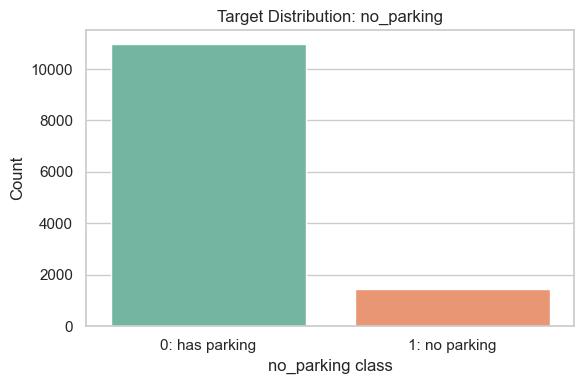

In [5]:
parking_distribution = summarize_class_distribution(df["parking"])
parking_distribution["meaning"] = parking_distribution["class"].map({0: "does not have parking", 1: "has parking"})
display(parking_distribution)

raw_target_preview = df.copy()
raw_target_preview[TARGET_COL] = 1 - raw_target_preview["parking"]
no_parking_distribution = summarize_class_distribution(raw_target_preview[TARGET_COL])
no_parking_distribution["meaning"] = no_parking_distribution["class"].map({0: "has parking", 1: "does not have parking"})
display(no_parking_distribution)

warehouse_distribution = summarize_class_distribution(df["warehouse"])
warehouse_distribution["meaning"] = warehouse_distribution["class"].map({0: "no warehouse", 1: "has warehouse"})
display(warehouse_distribution)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=TARGET_COL, data=raw_target_preview, ax=ax, palette="Set2")
ax.set_title("Target Distribution: no_parking")
ax.set_xlabel("no_parking class")
ax.set_ylabel("Count")
ax.set_xticklabels(["0: has parking", "1: no parking"])
plt.tight_layout()
plt.show()


The minority class is `no_parking = 1`. This is useful because recall now means: among apartments without parking, how many did the model find? Precision means: among apartments predicted as no parking, how many were really without parking?


## Data Cleaning and Validation

We create a cleaned dataframe without changing the original CSV. The misspelled `elavator` column is renamed to `elevator` in the cleaned dataframe for readability. We also create the target and run safety checks.


In [6]:
raw_required_columns = [
    "total_value",
    "neighborhood",
    "area",
    "year",
    "deposit",
    "rent",
    "elavator",
    "parking",
    "warehouse",
]
validate_required_columns(df, raw_required_columns)
for binary_col in ["parking", "elavator", "warehouse"]:
    validate_binary_column(df, binary_col)

cleaned_df = standardize_column_names(df)
cleaned_df = rename_known_typos(cleaned_df)
cleaned_df = create_target_no_parking(cleaned_df)
cleaned_df = remove_duplicate_rows(cleaned_df)

clean_required_columns = [
    "total_value",
    "neighborhood",
    "area",
    "year",
    "deposit",
    "rent",
    "elevator",
    "parking",
    "warehouse",
    TARGET_COL,
]
validate_required_columns(cleaned_df, clean_required_columns)
for binary_col in ["parking", "elevator", "warehouse", TARGET_COL]:
    validate_binary_column(cleaned_df, binary_col)

display(report_basic_quality(cleaned_df))
display(validate_numeric_ranges(cleaned_df))
display(cleaned_df.head())


,metric,value
0,rows,12383
1,columns,10
2,missing_values,0
3,duplicated_rows,0


,column,min,median,q99,max,zero_count,note
0,total_value,0.0000,"300,000,000.0000","3,500,000,000.0000","50,000,135,000.0000",1536,max is far above the 99th percentile
1,area,5.0000,115.0000,370.0000,"300,000.0000",0,area max is extremely large for a normal apart...
2,year,"1,363.0000","1,393.0000","1,399.0000","1,399.0000",0,ok / review with domain knowledge
3,deposit,0.0000,"300,000,000.0000","3,500,000,000.0000","50,000,000,000.0000",1564,contains zero values; max is far above the 99t...
4,rent,0.0000,"1,500,000.0000","60,000,000.0000","35,000,000,000.0000",5558,contains zero values; max is far above the 99t...


,total_value,neighborhood,area,year,deposit,rent,elevator,parking,warehouse,no_parking
0,"2,000,900,000.0000",ولنجک,270,1399,"2,000,000,000.0000","30,000,000.0000",1,1,1,0
1,"200,120,000.0000",کوی فردوس,70,1387,"200,000,000.0000","4,000,000.0000",0,1,1,0
2,"350,255,000.0000",پونک,120,1395,"350,000,000.0000","8,500,000.0000",1,1,1,0
3,"200,300,000.0000",هروی,110,1395,"200,000,000.0000","10,000,000.0000",1,1,1,0
4,"200,180,000.0000",پونک,80,1387,"200,000,000.0000","6,000,000.0000",1,1,1,0


## Feature and Target Split

The original `parking` column must not be used as a feature because it directly defines the target. Keeping it would be target leakage. We also remove `no_parking` from the features.


In [7]:
X = cleaned_df.drop(columns=["parking", TARGET_COL])
y = cleaned_df[TARGET_COL].astype(int)

numeric_features = ["total_value", "area", "year", "deposit", "rent"]
categorical_features = ["neighborhood"]
binary_features = ["elevator", "warehouse"]

all_feature_groups = numeric_features + categorical_features + binary_features
validate_required_columns(X, all_feature_groups)
assert "parking" not in X.columns
assert TARGET_COL not in X.columns

feature_groups = pd.DataFrame(
    {
        "feature": all_feature_groups,
        "group": ["numeric"] * len(numeric_features)
        + ["categorical"] * len(categorical_features)
        + ["binary"] * len(binary_features),
    }
)
display(feature_groups)
display(summarize_class_distribution(y))


,feature,group
0,total_value,numeric
1,area,numeric
2,year,numeric
3,deposit,numeric
4,rent,numeric
5,neighborhood,categorical
6,elevator,binary
7,warehouse,binary


,class,count,percent
0,0,10958,88.4900
1,1,1425,11.5100


## Stratified Train/Test Split

We use one fixed stratified split for all methods. The test set remains untouched and is never resampled. This keeps the comparison fair and realistic.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_dist = summarize_class_distribution(y_train).assign(split="train")
test_dist = summarize_class_distribution(y_test).assign(split="test")
display(pd.concat([train_dist, test_dist], ignore_index=True)[["split", "class", "count", "percent"]])
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


,split,class,count,percent
0,train,0,8766,88.4900
1,train,1,1140,11.5100
2,test,0,2192,88.4900
3,test,1,285,11.5100


Train shape: (9906, 8)
Test shape: (2477, 8)


## Preprocessing Pipeline

Every model uses the same preprocessing design:

- Numeric columns: median imputation and standard scaling.
- Categorical column: most-frequent imputation and one-hot encoding.
- Binary columns: most-frequent imputation.

The helper returns a fresh preprocessor each time, so separate model pipelines do not accidentally share fitted state.


In [9]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor():
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )
    binary_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
            ("binary", binary_transformer, binary_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


preprocessor = build_preprocessor()
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per

## Evaluation Utilities

Accuracy alone is misleading for this dataset because a model can mostly predict the majority class and still look strong. We therefore track balanced accuracy, minority-class precision, recall, F1, macro F1, weighted F1, ROC-AUC, and PR-AUC.

Since `no_parking = 1` is the minority-positive class, the default positive label of 1 is exactly what we want.


In [10]:
results = []
fitted_models = {}


def make_logistic_regression(**kwargs):
    params = {"max_iter": 1000, "random_state": RANDOM_STATE}
    params.update(kwargs)
    return LogisticRegression(**params)


def make_sklearn_pipeline(classifier):
    return Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("classifier", classifier),
        ]
    )


def make_imb_pipeline(sampler, classifier):
    return ImbPipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("sampler", sampler),
            ("classifier", classifier),
        ]
    )


def get_positive_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    return None


def evaluate_binary_model(
    name,
    model,
    X_test,
    y_test,
    method,
    sampler="None",
    sampling_strategy="None",
    classifier="LogisticRegression",
):
    y_pred = model.predict(X_test)
    y_score = get_positive_scores(model, X_test)

    row = {
        "model_name": name,
        "method": method,
        "sampler": sampler,
        "sampling_strategy": sampling_strategy,
        "classifier": classifier,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "roc_auc": np.nan if y_score is None else roc_auc_score(y_test, y_score),
        "pr_auc": np.nan if y_score is None else average_precision_score(y_test, y_score),
    }
    results.append(row)
    fitted_models[name] = model

    display(pd.DataFrame([row]))
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["has parking", "no parking"],
            zero_division=0,
        )
    )
    return row


def collect_results():
    return pd.DataFrame(results).sort_values(
        by=["pr_auc", "f1", "balanced_accuracy"], ascending=False, na_position="last"
    )


def plot_confusion_matrix_for_model(name, model, X_test, y_test, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["has parking", "no parking"],
        yticklabels=["has parking", "no parking"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    return ax


def plot_roc_pr_curves(model_names, X_test, y_test):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for name in model_names:
        model = fitted_models[name]
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name=name)
        PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=name)
    axes[0].set_title("ROC Curves")
    axes[1].set_title("Precision-Recall Curves")
    axes[0].grid(True)
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()


def plot_results_comparison(results_df):
    metrics = ["recall", "f1", "pr_auc", "balanced_accuracy"]
    titles = ["Minority Recall", "Minority F1", "PR-AUC", "Balanced Accuracy"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    for ax, metric, title in zip(axes.ravel(), metrics, titles):
        order = results_df.sort_values(metric, ascending=False)
        sns.barplot(data=order, y="model_name", x=metric, ax=ax, palette="Set2")
        ax.set_title(title)
        ax.set_xlabel(metric)
        ax.set_ylabel("")
        ax.set_xlim(0, min(1.0, max(0.05, order[metric].max() * 1.10)))
    plt.tight_layout()
    plt.show()


def resampled_distribution_table(sampler, X_train, y_train, label):
    local_preprocessor = build_preprocessor()
    X_train_prepared = local_preprocessor.fit_transform(X_train)
    _, y_resampled = sampler.fit_resample(X_train_prepared, y_train)
    return summarize_class_distribution(pd.Series(y_resampled, name=TARGET_COL)).assign(setting=label)


## Baseline Models Without Imbalance Treatment

The DummyClassifier is the naive majority-class baseline. LogisticRegression is the main baseline classifier without class weights or resampling.


In [11]:
dummy_model = make_sklearn_pipeline(DummyClassifier(strategy="most_frequent"))
dummy_model.fit(X_train, y_train)
evaluate_binary_model(
    "Dummy most frequent",
    dummy_model,
    X_test,
    y_test,
    method="Baseline",
    sampler="None",
    sampling_strategy="None",
    classifier="DummyClassifier",
)

baseline_lr_model = make_sklearn_pipeline(make_logistic_regression())
baseline_lr_model.fit(X_train, y_train)
evaluate_binary_model(
    "Logistic Regression baseline",
    baseline_lr_model,
    X_test,
    y_test,
    method="Baseline",
    sampler="None",
    sampling_strategy="None",
    classifier="LogisticRegression",
)


,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,Dummy most frequent,Baseline,None,None,DummyClassifier,0.8849,0.5000,0.0000,0.0000,0.0000,0.4695,0.8309,0.5000,0.1151


              precision    recall  f1-score   support

 has parking       0.88      1.00      0.94      2192
  no parking       0.00      0.00      0.00       285

    accuracy                           0.88      2477
   macro avg       0.44      0.50      0.47      2477
weighted avg       0.78      0.88      0.83      2477



,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,Logistic Regression baseline,Baseline,None,None,LogisticRegression,0.9035,0.6830,0.6278,0.3965,0.4860,0.7164,0.8937,0.9115,0.5819


              precision    recall  f1-score   support

 has parking       0.93      0.97      0.95      2192
  no parking       0.63      0.40      0.49       285

    accuracy                           0.90      2477
   macro avg       0.78      0.68      0.72      2477
weighted avg       0.89      0.90      0.89      2477



{'model_name': 'Logistic Regression baseline',
 'method': 'Baseline',
 'sampler': 'None',
 'sampling_strategy': 'None',
 'classifier': 'LogisticRegression',
 'accuracy': 0.9035123132821962,
 'balanced_accuracy': 0.6829627673197592,
 'precision': 0.6277777777777778,
 'recall': 0.39649122807017545,
 'f1': 0.4860215053763441,
 'macro_f1': 0.7163901244858998,
 'weighted_f1': 0.8937469903082345,
 'roc_auc': 0.9115299654245101,
 'pr_auc': 0.5818788433274401}

## Random Undersampling

Random undersampling removes examples from the majority class in the training data. It can improve minority recall, but it may also lose useful majority-class information.

For a binary task, a float `sampling_strategy` means the desired ratio: minority samples divided by majority samples after resampling. A smaller value keeps more majority samples; `1.00` balances the classes.


,class,count,percent,setting
0,0,8766,88.4900,Before resampling
1,1,1140,11.5100,Before resampling
2,0,3800,76.9200,Under 0.30
3,1,1140,23.0800,Under 0.30
4,0,2280,66.6700,Under 0.50
5,1,1140,33.3300,Under 0.50
6,0,1140,50.0000,Under 1.00
7,1,1140,50.0000,Under 1.00


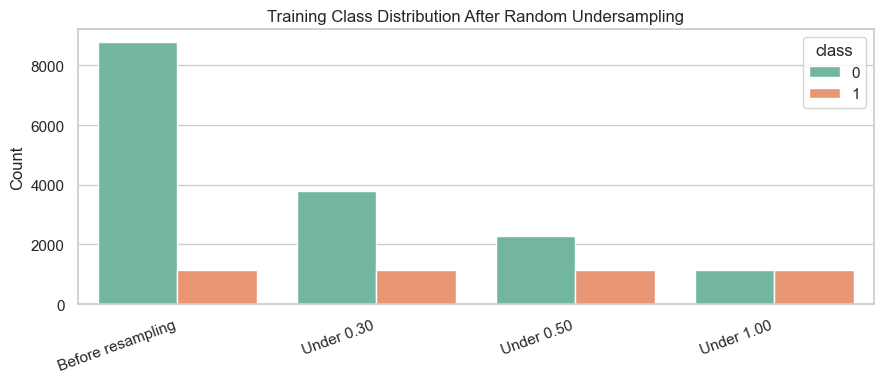

,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomUnderSampler 0.30,Random undersampling,RandomUnderSampler,0.3000,LogisticRegression,0.8914,0.7646,0.5245,0.6000,0.5597,0.7489,0.8945,0.9105,0.5825


              precision    recall  f1-score   support

 has parking       0.95      0.93      0.94      2192
  no parking       0.52      0.60      0.56       285

    accuracy                           0.89      2477
   macro avg       0.74      0.76      0.75      2477
weighted avg       0.90      0.89      0.89      2477



,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomUnderSampler 0.50,Random undersampling,RandomUnderSampler,0.5000,LogisticRegression,0.8712,0.7990,0.4610,0.7053,0.5576,0.7411,0.8824,0.9074,0.5490


              precision    recall  f1-score   support

 has parking       0.96      0.89      0.92      2192
  no parking       0.46      0.71      0.56       285

    accuracy                           0.87      2477
   macro avg       0.71      0.80      0.74      2477
weighted avg       0.90      0.87      0.88      2477



,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomUnderSampler 1.00,Random undersampling,RandomUnderSampler,1.0000,LogisticRegression,0.8304,0.8401,0.3913,0.8526,0.5364,0.7163,0.8548,0.9056,0.5425


              precision    recall  f1-score   support

 has parking       0.98      0.83      0.90      2192
  no parking       0.39      0.85      0.54       285

    accuracy                           0.83      2477
   macro avg       0.68      0.84      0.72      2477
weighted avg       0.91      0.83      0.85      2477



In [12]:
under_strategies = [0.30, 0.50, 1.00]
under_distributions = [summarize_class_distribution(y_train).assign(setting="Before resampling")]

for strategy in under_strategies:
    sampler = RandomUnderSampler(sampling_strategy=strategy, random_state=RANDOM_STATE)
    under_distributions.append(
        resampled_distribution_table(sampler, X_train, y_train, f"Under {strategy:.2f}")
    )

under_distribution_df = pd.concat(under_distributions, ignore_index=True)
display(under_distribution_df)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=under_distribution_df, x="setting", y="count", hue="class", ax=ax, palette="Set2")
ax.set_title("Training Class Distribution After Random Undersampling")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

for strategy in under_strategies:
    model = make_imb_pipeline(
        RandomUnderSampler(sampling_strategy=strategy, random_state=RANDOM_STATE),
        make_logistic_regression(),
    )
    model.fit(X_train, y_train)
    evaluate_binary_model(
        f"RandomUnderSampler {strategy:.2f}",
        model,
        X_test,
        y_test,
        method="Random undersampling",
        sampler="RandomUnderSampler",
        sampling_strategy=strategy,
        classifier="LogisticRegression",
    )


In this part I used random undersampling to reduce the number of majority class samples.
The assignment asks to apply undersampling and compare different strategies.
The recall of the no parking class increased when the data became more balanced.
However stronger undersampling reduced accuracy because some useful majority data was removed.

## Random Oversampling

Random oversampling duplicates minority-class training samples. It can improve recall because the classifier sees more minority examples, but it can also overfit repeated rows.


,class,count,percent,setting
0,0,8766,88.4900,Before resampling
1,1,1140,11.5100,Before resampling
2,0,8766,76.9300,Over 0.30
3,1,2629,23.0700,Over 0.30
4,0,8766,66.6700,Over 0.50
5,1,4383,33.3300,Over 0.50
6,0,8766,50.0000,Over 1.00
7,1,8766,50.0000,Over 1.00


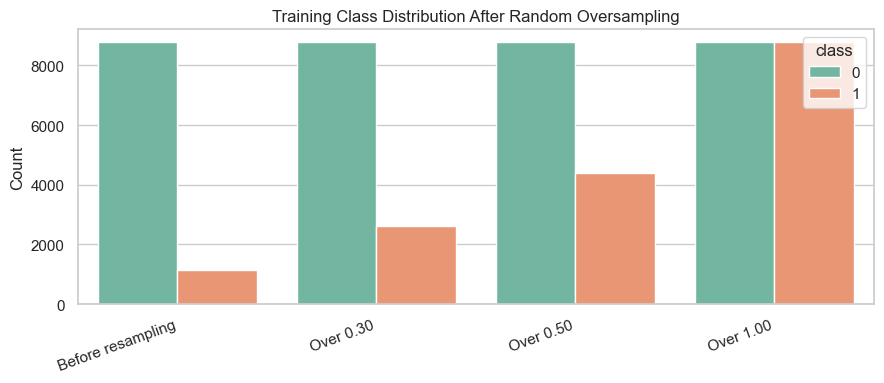

,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomOverSampler 0.30,Random oversampling,RandomOverSampler,0.3000,LogisticRegression,0.8918,0.7633,0.5263,0.5965,0.5592,0.7488,0.8947,0.9125,0.5772


              precision    recall  f1-score   support

 has parking       0.95      0.93      0.94      2192
  no parking       0.53      0.60      0.56       285

    accuracy                           0.89      2477
   macro avg       0.74      0.76      0.75      2477
weighted avg       0.90      0.89      0.89      2477



,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomOverSampler 0.50,Random oversampling,RandomOverSampler,0.5000,LogisticRegression,0.8736,0.8034,0.4677,0.7123,0.5647,0.7454,0.8845,0.9119,0.5720


              precision    recall  f1-score   support

 has parking       0.96      0.89      0.93      2192
  no parking       0.47      0.71      0.56       285

    accuracy                           0.87      2477
   macro avg       0.71      0.80      0.75      2477
weighted avg       0.90      0.87      0.88      2477



,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomOverSampler 1.00,Random oversampling,RandomOverSampler,1.0000,LogisticRegression,0.8365,0.8374,0.3997,0.8386,0.5413,0.7209,0.8592,0.9117,0.5697


              precision    recall  f1-score   support

 has parking       0.98      0.84      0.90      2192
  no parking       0.40      0.84      0.54       285

    accuracy                           0.84      2477
   macro avg       0.69      0.84      0.72      2477
weighted avg       0.91      0.84      0.86      2477



In [13]:
over_strategies = [0.30, 0.50, 1.00]
over_distributions = [summarize_class_distribution(y_train).assign(setting="Before resampling")]

for strategy in over_strategies:
    sampler = RandomOverSampler(sampling_strategy=strategy, random_state=RANDOM_STATE)
    over_distributions.append(
        resampled_distribution_table(sampler, X_train, y_train, f"Over {strategy:.2f}")
    )

over_distribution_df = pd.concat(over_distributions, ignore_index=True)
display(over_distribution_df)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=over_distribution_df, x="setting", y="count", hue="class", ax=ax, palette="Set2")
ax.set_title("Training Class Distribution After Random Oversampling")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

for strategy in over_strategies:
    model = make_imb_pipeline(
        RandomOverSampler(sampling_strategy=strategy, random_state=RANDOM_STATE),
        make_logistic_regression(),
    )
    model.fit(X_train, y_train)
    evaluate_binary_model(
        f"RandomOverSampler {strategy:.2f}",
        model,
        X_test,
        y_test,
        method="Random oversampling",
        sampler="RandomOverSampler",
        sampling_strategy=strategy,
        classifier="LogisticRegression",
    )


In this part I used random oversampling to increase the number of minority class samples.
The assignment asks to apply oversampling and compare it with undersampling.
Oversampling improved minority recall while keeping all majority samples.
The result was close to undersampling but it may overfit because it repeats minority rows.

## SMOTE

SMOTE creates synthetic minority-class samples instead of only duplicating existing rows. It selects a minority sample, finds one of its nearest minority neighbors, and creates a new point by interpolating between them.

This is different from random oversampling because the added samples are new synthetic points. In this notebook SMOTE is applied after one-hot encoding. That is acceptable for an educational comparison with a linear model, but it can create fractional values in one-hot feature space. For categorical-heavy data, `SMOTENC` would be a more specialized future improvement.


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,class,count,percent,setting
0,0,8766,88.4900,Before resampling
1,1,1140,11.5100,Before resampling
2,0,8766,66.6700,SMOTE 0.50
3,1,4383,33.3300,SMOTE 0.50
4,0,8766,50.0000,SMOTE 1.00
5,1,8766,50.0000,SMOTE 1.00


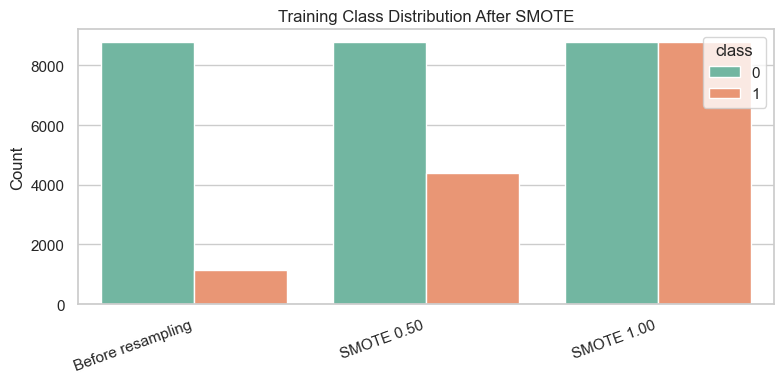

,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,SMOTE 0.50,SMOTE,SMOTE,0.5000,LogisticRegression,0.8789,0.8125,0.4825,0.7263,0.5798,0.7545,0.8890,0.9130,0.5757


              precision    recall  f1-score   support

 has parking       0.96      0.90      0.93      2192
  no parking       0.48      0.73      0.58       285

    accuracy                           0.88      2477
   macro avg       0.72      0.81      0.75      2477
weighted avg       0.91      0.88      0.89      2477



,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,SMOTE 1.00,SMOTE,SMOTE,1.0000,LogisticRegression,0.8454,0.8394,0.4143,0.8316,0.5531,0.7298,0.8659,0.9130,0.5727


              precision    recall  f1-score   support

 has parking       0.97      0.85      0.91      2192
  no parking       0.41      0.83      0.55       285

    accuracy                           0.85      2477
   macro avg       0.69      0.84      0.73      2477
weighted avg       0.91      0.85      0.87      2477



In [14]:
smote_strategies = [0.50, 1.00]
smote_distributions = [summarize_class_distribution(y_train).assign(setting="Before resampling")]

for strategy in smote_strategies:
    sampler = SMOTE(sampling_strategy=strategy, random_state=RANDOM_STATE, k_neighbors=5)
    smote_distributions.append(
        resampled_distribution_table(sampler, X_train, y_train, f"SMOTE {strategy:.2f}")
    )

smote_distribution_df = pd.concat(smote_distributions, ignore_index=True)
display(smote_distribution_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=smote_distribution_df, x="setting", y="count", hue="class", ax=ax, palette="Set2")
ax.set_title("Training Class Distribution After SMOTE")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

for strategy in smote_strategies:
    model = make_imb_pipeline(
        SMOTE(sampling_strategy=strategy, random_state=RANDOM_STATE, k_neighbors=5),
        make_logistic_regression(),
    )
    model.fit(X_train, y_train)
    evaluate_binary_model(
        f"SMOTE {strategy:.2f}",
        model,
        X_test,
        y_test,
        method="SMOTE",
        sampler="SMOTE",
        sampling_strategy=strategy,
        classifier="LogisticRegression",
    )


In this part I used SMOTE to create synthetic minority class samples.
The assignment asks to explain how SMOTE works and compare it with simple oversampling.
SMOTE gave better F1 for the minority class than the baseline model.
It improved recall but it must be used carefully because categorical features can become fractional.

## Cost-Sensitive Learning

Cost-sensitive learning does not change the training data distribution. Instead, it makes mistakes on the minority class more expensive during training. This can improve minority recall without duplicating or synthesizing samples.


In [15]:
classes = np.sort(y_train.unique())
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
class_weight_table = pd.DataFrame(
    {
        "class": classes,
        "meaning": ["has parking", "no parking"],
        "class_weight": class_weights,
    }
)
display(class_weight_table)

cost_sensitive_lr_model = make_sklearn_pipeline(make_logistic_regression(class_weight="balanced"))
cost_sensitive_lr_model.fit(X_train, y_train)
evaluate_binary_model(
    "Cost-sensitive Logistic Regression",
    cost_sensitive_lr_model,
    X_test,
    y_test,
    method="Cost-sensitive learning",
    sampler="None",
    sampling_strategy="class_weight=balanced",
    classifier="LogisticRegression",
)


,class,meaning,class_weight
0,0,has parking,0.5650
1,1,no parking,4.3447


,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,Cost-sensitive Logistic Regression,Cost-sensitive learning,None,class_weight=balanced,LogisticRegression,0.8405,0.8458,0.4077,0.8526,0.5516,0.7273,0.8626,0.9130,0.5753


              precision    recall  f1-score   support

 has parking       0.98      0.84      0.90      2192
  no parking       0.41      0.85      0.55       285

    accuracy                           0.84      2477
   macro avg       0.69      0.85      0.73      2477
weighted avg       0.91      0.84      0.86      2477



{'model_name': 'Cost-sensitive Logistic Regression',
 'method': 'Cost-sensitive learning',
 'sampler': 'None',
 'sampling_strategy': 'class_weight=balanced',
 'classifier': 'LogisticRegression',
 'accuracy': 0.8405329027048849,
 'balanced_accuracy': 0.8457957164809835,
 'precision': 0.4077181208053691,
 'recall': 0.8526315789473684,
 'f1': 0.5516458569807038,
 'macro_f1': 0.7273328720209191,
 'weighted_f1': 0.8625913046740037,
 'roc_auc': 0.9129978230247151,
 'pr_auc': 0.5752557364554349}

In this part I used class weights instead of changing the data distribution.
The assignment asks to compute class weights and add them to the classifier.
This method gave high recall for the minority class and did not create new rows.
The precision was lower but the model became better at finding no parking samples.

## Optional Lightweight RandomForest Comparison

A small RandomForest comparison is included to check whether the same imbalance ideas behave differently for a non-linear model. This is intentionally lightweight and does not do a large grid search.


In [16]:
rf_baseline_model = make_sklearn_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=3,
    )
)
rf_baseline_model.fit(X_train, y_train)
evaluate_binary_model(
    "RandomForest baseline",
    rf_baseline_model,
    X_test,
    y_test,
    method="Optional RandomForest",
    sampler="None",
    sampling_strategy="None",
    classifier="RandomForestClassifier",
)

rf_weighted_model = make_sklearn_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=3,
    )
)
rf_weighted_model.fit(X_train, y_train)
evaluate_binary_model(
    "RandomForest class_weight balanced",
    rf_weighted_model,
    X_test,
    y_test,
    method="Optional RandomForest",
    sampler="None",
    sampling_strategy="class_weight=balanced",
    classifier="RandomForestClassifier",
)


,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomForest baseline,Optional RandomForest,None,None,RandomForestClassifier,0.9128,0.6836,0.7285,0.3860,0.5046,0.7284,0.9007,0.9309,0.6451


              precision    recall  f1-score   support

 has parking       0.92      0.98      0.95      2192
  no parking       0.73      0.39      0.50       285

    accuracy                           0.91      2477
   macro avg       0.83      0.68      0.73      2477
weighted avg       0.90      0.91      0.90      2477



,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomForest class_weight balanced,Optional RandomForest,None,class_weight=balanced,RandomForestClassifier,0.8498,0.8571,0.4251,0.8667,0.5704,0.7397,0.8700,0.9308,0.6389


              precision    recall  f1-score   support

 has parking       0.98      0.85      0.91      2192
  no parking       0.43      0.87      0.57       285

    accuracy                           0.85      2477
   macro avg       0.70      0.86      0.74      2477
weighted avg       0.92      0.85      0.87      2477



{'model_name': 'RandomForest class_weight balanced',
 'method': 'Optional RandomForest',
 'sampler': 'None',
 'sampling_strategy': 'class_weight=balanced',
 'classifier': 'RandomForestClassifier',
 'accuracy': 0.8498183286233347,
 'balanced_accuracy': 0.8571472019464721,
 'precision': 0.42512908777969016,
 'recall': 0.8666666666666667,
 'f1': 0.5704387990762124,
 'macro_f1': 0.7397203780116874,
 'weighted_f1': 0.8700473747940657,
 'roc_auc': 0.9307865923933925,
 'pr_auc': 0.6389137338666613}

## Final Comparison Table

Now we combine all model results into one table. The primary ranking uses PR-AUC because it focuses on positive-class ranking quality under imbalance. F1 and balanced accuracy are useful secondary checks.


In [17]:
results_df = collect_results().reset_index(drop=True)
metric_columns = [
    "model_name",
    "method",
    "sampler",
    "sampling_strategy",
    "classifier",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "macro_f1",
    "weighted_f1",
    "roc_auc",
    "pr_auc",
]
results_df = results_df[metric_columns]
results_df.to_csv(OUTPUT_DIR / "part2_model_results.csv", index=False)

display(results_df)
print("Top 5 methods by PR-AUC, then F1, then balanced accuracy:")
display(results_df.head(5))


,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomForest baseline,Optional RandomForest,None,None,RandomForestClassifier,0.9128,0.6836,0.7285,0.3860,0.5046,0.7284,0.9007,0.9309,0.6451
1,RandomForest class_weight balanced,Optional RandomForest,None,class_weight=balanced,RandomForestClassifier,0.8498,0.8571,0.4251,0.8667,0.5704,0.7397,0.8700,0.9308,0.6389
2,RandomUnderSampler 0.30,Random undersampling,RandomUnderSampler,0.3000,LogisticRegression,0.8914,0.7646,0.5245,0.6000,0.5597,0.7489,0.8945,0.9105,0.5825
3,Logistic Regression baseline,Baseline,None,None,LogisticRegression,0.9035,0.6830,0.6278,0.3965,0.4860,0.7164,0.8937,0.9115,0.5819
4,RandomOverSampler 0.30,Random oversampling,RandomOverSampler,0.3000,LogisticRegression,0.8918,0.7633,0.5263,0.5965,0.5592,0.7488,0.8947,0.9125,0.5772
5,SMOTE 0.50,SMOTE,SMOTE,0.5000,LogisticRegression,0.8789,0.8125,0.4825,0.7263,0.5798,0.7545,0.8890,0.9130,0.5757
6,Cost-sensitive Logistic Regression,Cost-sensitive learning,None,class_weight=balanced,LogisticRegression,0.8405,0.8458,0.4077,0.8526,0.5516,0.7273,0.8626,0.9130,0.5753
7,SMOTE 1.00,SMOTE,SMOTE,1.0000,LogisticRegression,0.8454,0.8394,0.4143,0.8316,0.5531,0.7298,0.8659,0.9130,0.5727
8,RandomOverSampler 0.50,Random oversampling,RandomOverSampler,0.5000,LogisticRegression,0.8736,0.8034,0.4677,0.7123,0.5647,0.7454,0.8845,0.9119,0.5720
9,RandomOverSampler 1.00,Random oversampling,RandomOverSampler,1.0000,LogisticRegression,0.8365,0.8374,0.3997,0.8386,0.5413,0.7209,0.8592,0.9117,0.5697


Top 5 methods by PR-AUC, then F1, then balanced accuracy:


,model_name,method,sampler,sampling_strategy,classifier,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,pr_auc
0,RandomForest baseline,Optional RandomForest,None,None,RandomForestClassifier,0.9128,0.6836,0.7285,0.3860,0.5046,0.7284,0.9007,0.9309,0.6451
1,RandomForest class_weight balanced,Optional RandomForest,None,class_weight=balanced,RandomForestClassifier,0.8498,0.8571,0.4251,0.8667,0.5704,0.7397,0.8700,0.9308,0.6389
2,RandomUnderSampler 0.30,Random undersampling,RandomUnderSampler,0.3000,LogisticRegression,0.8914,0.7646,0.5245,0.6000,0.5597,0.7489,0.8945,0.9105,0.5825
3,Logistic Regression baseline,Baseline,None,None,LogisticRegression,0.9035,0.6830,0.6278,0.3965,0.4860,0.7164,0.8937,0.9115,0.5819
4,RandomOverSampler 0.30,Random oversampling,RandomOverSampler,0.3000,LogisticRegression,0.8918,0.7633,0.5263,0.5965,0.5592,0.7488,0.8947,0.9125,0.5772


## Metric Comparison Plots

These plots compare the most important metrics across all methods: minority recall, minority F1, PR-AUC, and balanced accuracy.


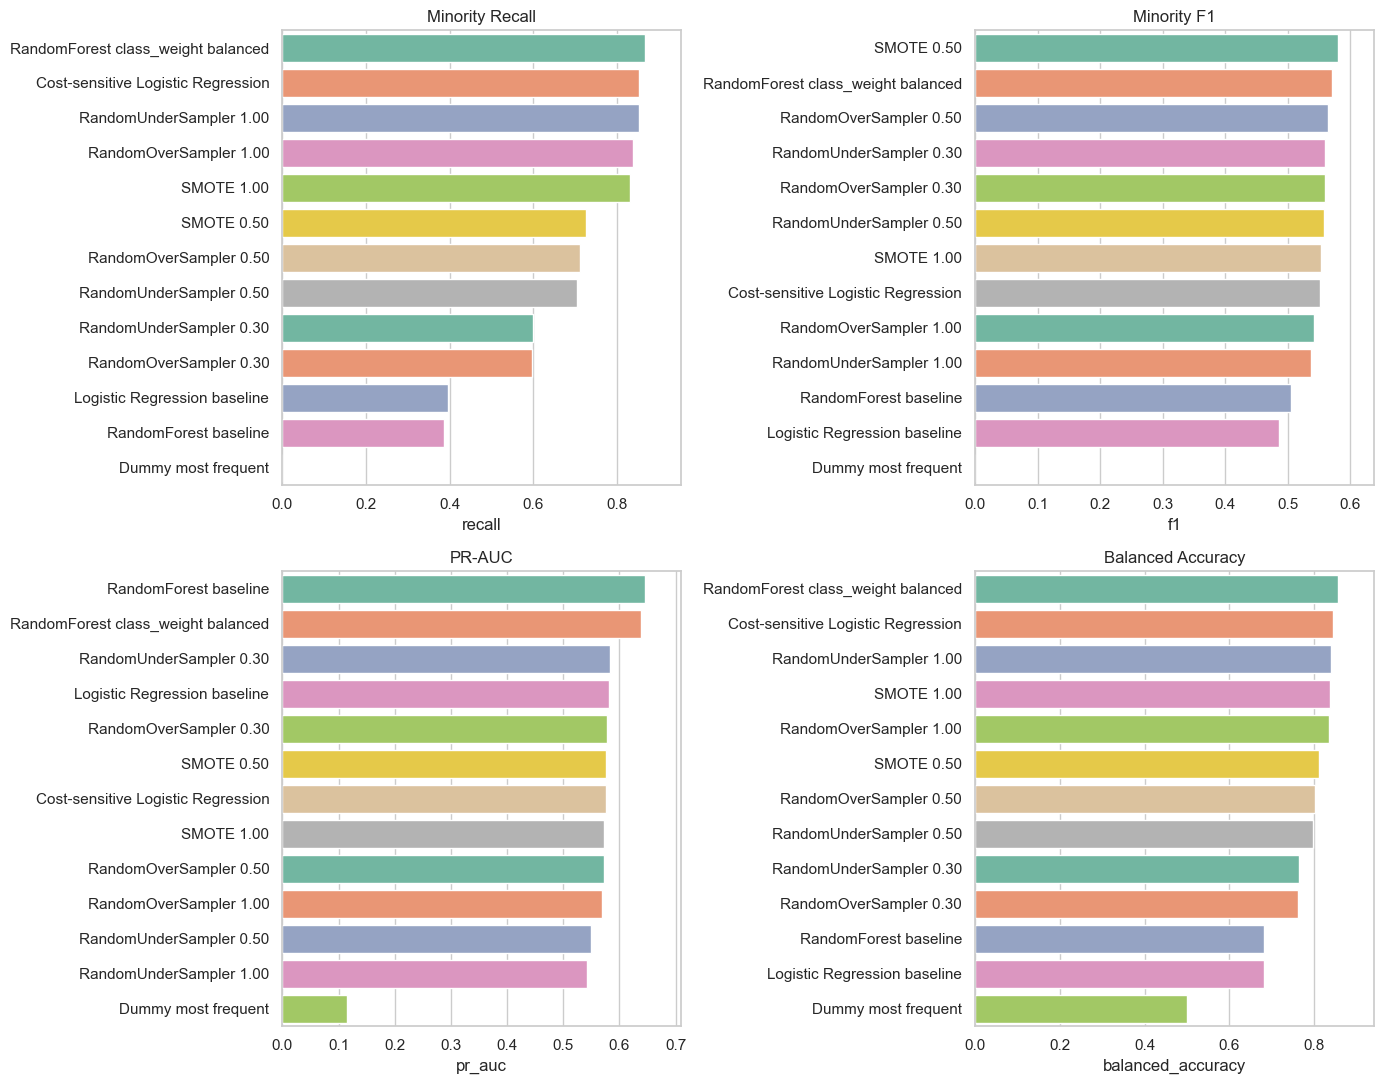

In [18]:
plot_results_comparison(results_df)


## Confusion Matrices and Curves

The next plots compare the baseline LogisticRegression, the best undersampling model, the best oversampling model, the best SMOTE model, and the cost-sensitive LogisticRegression. All of them are evaluated on the same untouched test set.


['Logistic Regression baseline', 'RandomUnderSampler 0.30', 'RandomOverSampler 0.30', 'SMOTE 0.50', 'Cost-sensitive Logistic Regression']


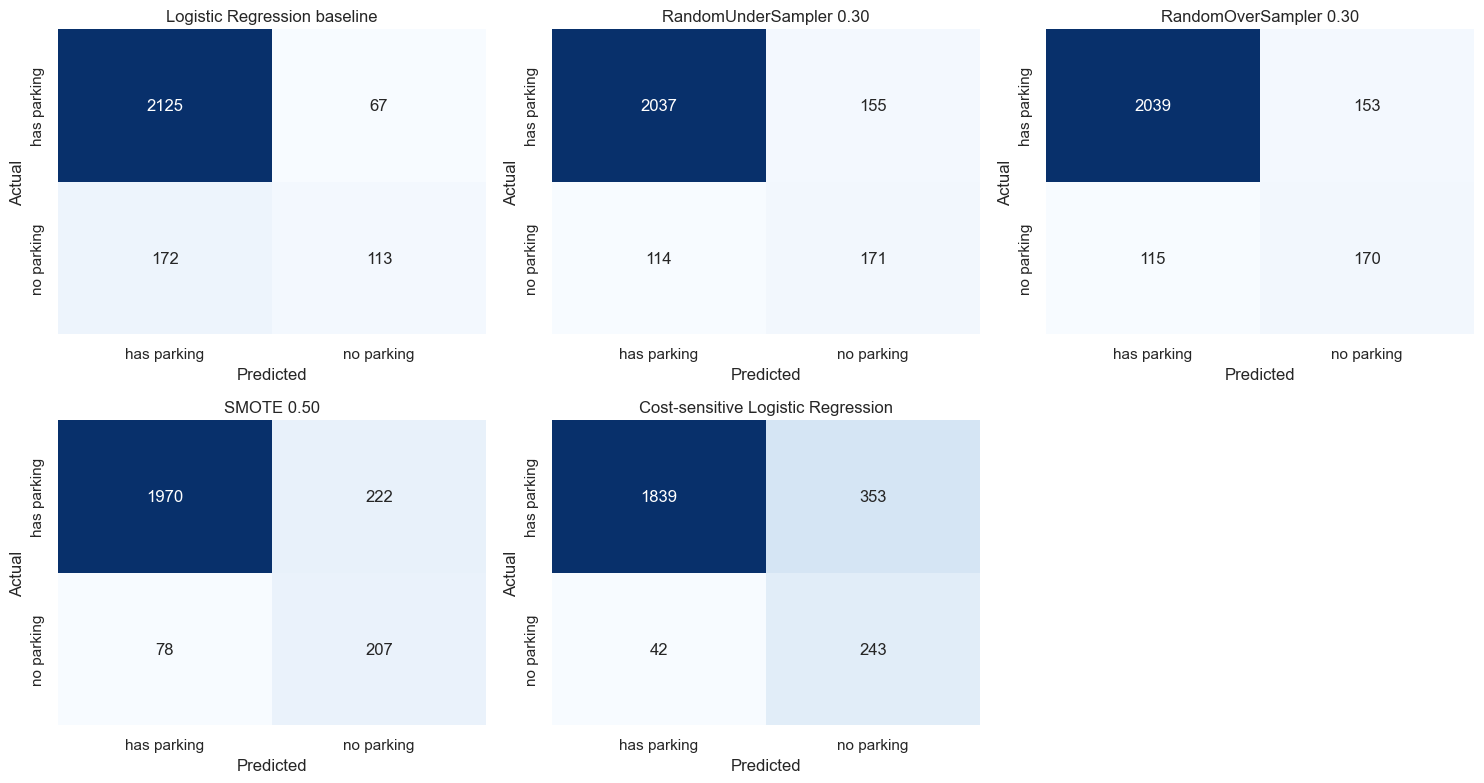

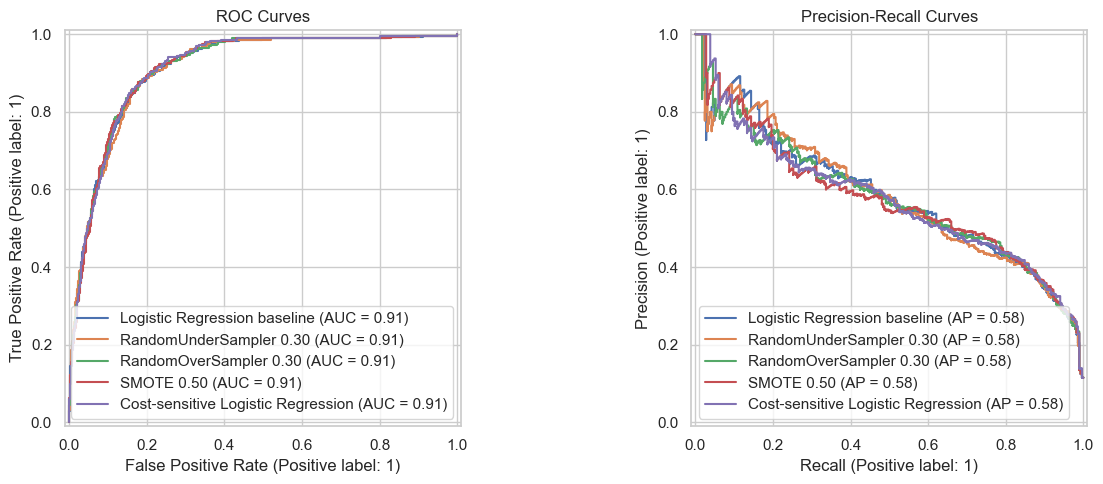

In [19]:
def best_model_name_for_method(method):
    subset = results_df[results_df["method"] == method]
    if subset.empty:
        return None
    return subset.sort_values(
        by=["pr_auc", "f1", "balanced_accuracy"], ascending=False, na_position="last"
    ).iloc[0]["model_name"]


selected_model_names = [
    "Logistic Regression baseline",
    best_model_name_for_method("Random undersampling"),
    best_model_name_for_method("Random oversampling"),
    best_model_name_for_method("SMOTE"),
    "Cost-sensitive Logistic Regression",
]
selected_model_names = list(dict.fromkeys([name for name in selected_model_names if name is not None]))
print(selected_model_names)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, name in zip(axes.ravel(), selected_model_names):
    plot_confusion_matrix_for_model(name, fitted_models[name], X_test, y_test, ax=ax)
for ax in axes.ravel()[len(selected_model_names):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

plot_roc_pr_curves(selected_model_names, X_test, y_test)


## Analysis and Interpretation

The table and plots above answer the main questions:

- Random undersampling usually increases minority recall because the model sees a less majority-dominated training set, but stronger undersampling may reduce precision because useful majority information is removed.
- Random oversampling keeps all majority samples and repeats minority rows. It often improves recall with less information loss than undersampling, but repeated samples can overfit.
- SMOTE creates synthetic minority samples and is more flexible than simple duplication. In this dataset, it should be compared carefully with random oversampling because one-hot encoded categorical features can become fractional after SMOTE.
- Cost-sensitive learning changes the loss function instead of the data. It is simple, fast, and avoids synthetic rows.
- Accuracy is misleading because the majority class is about 88.5 percent of the data. A model can predict almost everything as `has parking` and still show high accuracy while failing on apartments without parking.
- PR-AUC is especially appropriate here because the positive class is rare and we care about ranking/finding `no_parking = 1` examples.

The next code cell extracts the best method by PR-AUC, best method by recall, and a simple overall trade-off score.


In [20]:
summary_df = results_df.copy()
summary_df["tradeoff_score"] = summary_df[["f1", "balanced_accuracy", "pr_auc"]].mean(axis=1)

best_by_pr = summary_df.sort_values(["pr_auc", "f1", "balanced_accuracy"], ascending=False).iloc[0]
best_by_recall = summary_df.sort_values(["recall", "precision", "f1"], ascending=False).iloc[0]
best_tradeoff = summary_df.sort_values(["tradeoff_score", "pr_auc"], ascending=False).iloc[0]

final_summary_table = pd.DataFrame(
    [
        {
            "question": "Best method by PR-AUC",
            "model_name": best_by_pr["model_name"],
            "pr_auc": best_by_pr["pr_auc"],
            "recall": best_by_pr["recall"],
            "precision": best_by_pr["precision"],
            "f1": best_by_pr["f1"],
        },
        {
            "question": "Best method by minority recall",
            "model_name": best_by_recall["model_name"],
            "pr_auc": best_by_recall["pr_auc"],
            "recall": best_by_recall["recall"],
            "precision": best_by_recall["precision"],
            "f1": best_by_recall["f1"],
        },
        {
            "question": "Best overall trade-off",
            "model_name": best_tradeoff["model_name"],
            "pr_auc": best_tradeoff["pr_auc"],
            "recall": best_tradeoff["recall"],
            "precision": best_tradeoff["precision"],
            "f1": best_tradeoff["f1"],
        },
    ]
)
display(final_summary_table)

analysis_text = f"""
### Run-specific conclusions

- Best PR-AUC: **{best_by_pr['model_name']}** with PR-AUC {best_by_pr['pr_auc']:.3f}.
- Best minority recall: **{best_by_recall['model_name']}** with recall {best_by_recall['recall']:.3f}.
- Best overall trade-off by the simple average of F1, balanced accuracy, and PR-AUC: **{best_tradeoff['model_name']}**.
- The final choice depends on the cost of errors. If missing no-parking apartments is costly, choose the high-recall model. If false alarms are costly, prefer the model with better precision/F1.
"""
display(Markdown(analysis_text))


,question,model_name,pr_auc,recall,precision,f1
0,Best method by PR-AUC,RandomForest baseline,0.6451,0.3860,0.7285,0.5046
1,Best method by minority recall,RandomForest class_weight balanced,0.6389,0.8667,0.4251,0.5704
2,Best overall trade-off,RandomForest class_weight balanced,0.6389,0.8667,0.4251,0.5704



### Run-specific conclusions

- Best PR-AUC: **RandomForest baseline** with PR-AUC 0.645.
- Best minority recall: **RandomForest class_weight balanced** with recall 0.867.
- Best overall trade-off by the simple average of F1, balanced accuracy, and PR-AUC: **RandomForest class_weight balanced**.
- The final choice depends on the cost of errors. If missing no-parking apartments is costly, choose the high-recall model. If false alarms are costly, prefer the model with better precision/F1.
